# Hot Plasma Composition Analyzer
author: Louis Richard\
HPCA summary plot

In [1]:
%matplotlib widget
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from pyrfu import mms
from pyrfu.plot import plot_line, plot_spectr, make_labels
import pyrfu
pyrfu.plot.set_color_cycle(pal = "pyrfu")


Load IGRF coefficients ...


(['pyrfu:blue',
  'pyrfu:green',
  'pyrfu:red',
  'pyrfu:fg',
  'pyrfu:orange',
  'pyrfu:purple',
  'pyrfu:yellow',
  'pyrfu:lightblue',
  'pyrfu:olive'],
 'hot_white_desaturated')

## Define spacecraft index, time interval and species

In [10]:
ic = 1
mms.db_init(default="local", local="/data/mms")
tint = ['2017-07-29T09:23:37.103846566', '2017-07-29T09:24:37.103846566']
species = {
    "hplus": "$H^+$",
    "heplus": "$He^+$",
    "heplusplus": "$He^{2+}$",
    "oplus": "$O^+$",
}

[01-Jul-25 07:34:48] INFO: Updating MMS data access configuration in /homelocal/apostolosk/envs/mms_projects/lib/python3.12/site-packages/pyrfu/mms/config.json...
[01-Jul-25 07:34:48] INFO: Updating MMS SDC credentials in /homelocal/apostolosk/.config/python_keyring...


## Load data

### Load HPCA moments

In [11]:
n_hpca = [mms.get_data(f"n{s}_hpca_srvy_l2", tint, ic) for s in species.keys()]
n_hpca_brst = [mms.get_data(f"n{s}_hpca_brst_l2", tint, ic) for s in species.keys()]
v_xyz_hpca = [mms.get_data(f"v{s}_dbcs_hpca_srvy_l2", tint, ic) for s in species.keys()]
ancillary = mms.load_ancillary(product = "defatt", tint = tint, mms_id = ic, verbose = False)
v_xyz_hpca = [mms.dsl2gse(v_xyz_hpca[i], ancillary, direction = +1) for i in range(len(v_xyz_hpca))]

v_xyz_hpca_brst = [
    mms.get_data(f"v{s}_dbcs_hpca_brst_l2", tint, ic) for s in species.keys()
]
v_xyz_hpca_brst = [
    mms.dsl2gse(v_xyz_hpca_brst[i], ancillary, direction = +1)
    for i in range(len(v_xyz_hpca_brst))
]

[01-Jul-25 07:34:50] INFO: Loading mms1_hpca_hplus_number_density...
[01-Jul-25 07:34:50] INFO: Loading mms1_hpca_heplus_number_density...
[01-Jul-25 07:34:50] INFO: Loading mms1_hpca_heplusplus_number_density...
[01-Jul-25 07:34:50] INFO: Loading mms1_hpca_oplus_number_density...
[01-Jul-25 07:34:50] INFO: Loading mms1_hpca_hplus_number_density...
[01-Jul-25 07:34:50] INFO: Loading mms1_hpca_heplus_number_density...
[01-Jul-25 07:34:50] INFO: Loading mms1_hpca_heplusplus_number_density...
[01-Jul-25 07:34:50] INFO: Loading mms1_hpca_oplus_number_density...
[01-Jul-25 07:34:50] INFO: Loading mms1_hpca_hplus_ion_bulk_velocity...
[01-Jul-25 07:34:50] INFO: Loading mms1_hpca_heplus_ion_bulk_velocity...
[01-Jul-25 07:34:50] INFO: Loading mms1_hpca_heplusplus_ion_bulk_velocity...
[01-Jul-25 07:34:50] INFO: Loading mms1_hpca_oplus_ion_bulk_velocity...


[01-Jul-25 07:34:53] INFO: Loading mms1_hpca_hplus_ion_bulk_velocity...
[01-Jul-25 07:34:53] INFO: Loading mms1_hpca_heplus_ion_bulk_velocity...
[01-Jul-25 07:34:53] INFO: Loading mms1_hpca_heplusplus_ion_bulk_velocity...
[01-Jul-25 07:34:53] INFO: Loading mms1_hpca_oplus_ion_bulk_velocity...


### Load HPCA ion

In [12]:
flux_hpca = [mms.get_data(f"dpf{s}_hpca_srvy_l2", tint, ic) for s in species.keys()]
flux_hpca_brst = [
    mms.get_data(f"dpf{s}_hpca_brst_l2", tint, ic) for s in species.keys()
]

[01-Jul-25 07:34:55] INFO: Loading mms1_hpca_hplus_flux...
[01-Jul-25 07:34:55] INFO: Loading mms1_hpca_heplus_flux...
[01-Jul-25 07:34:55] INFO: Loading mms1_hpca_heplusplus_flux...
[01-Jul-25 07:34:55] INFO: Loading mms1_hpca_oplus_flux...
[01-Jul-25 07:34:56] INFO: Loading mms1_hpca_hplus_flux...
[01-Jul-25 07:34:56] INFO: Loading mms1_hpca_heplus_flux...
[01-Jul-25 07:34:56] INFO: Loading mms1_hpca_heplusplus_flux...
[01-Jul-25 07:34:56] INFO: Loading mms1_hpca_oplus_flux...


### Load magnetic field

In [13]:
b_xyz = mms.get_data("b_gse_fgm_srvy_l2", tint, ic)
b_xyz_brst = mms.get_data("b_gse_fgm_brst_l2", tint, ic)

[01-Jul-25 07:34:56] INFO: Loading mms1_fgm_b_gse_srvy_l2...
[01-Jul-25 07:34:56] INFO: Loading mms1_fgm_b_gse_brst_l2...


## Compute ion fluxes

In [14]:
def calc_hpca_flux(flux):
    flux.data[flux.data <= 0] = np.nan
    coords = [flux.time.data, flux.ccomp.data]
    dims = ["time", "energy"]

    out = xr.DataArray(
        np.nanmean(flux.data, axis=1), coords=coords, dims=dims, attrs=flux.attrs
    )
    return out


flux_hpca = [calc_hpca_flux(flux) for flux in flux_hpca]
flux_hpca_brst = [calc_hpca_flux(flux) for flux in flux_hpca_brst]

[01-Jul-25 07:34:57] WARNING: /tmp/ipykernel_29326/1029720784.py:7: RuntimeWarning: Mean of empty slice
  np.nanmean(flux.data, axis=1), coords=coords, dims=dims, attrs=flux.attrs



## Plot

In [15]:
legend_options = dict(
    ncol=1, frameon=False, loc="upper left", bbox_to_anchor=(1.0, 1.0)
)

array([<Axes: ylabel='$B_{GSE}$\n[nT]'>,
       <Axes: ylabel='$n$\n[cm$^{-3}$]'>, <Axes: ylabel='$E$\n[eV]'>,
       <Axes: ylabel='$E$\n[eV]'>, <Axes: ylabel='$E$\n[eV]'>,
       <Axes: ylabel='$E$\n[eV]'>], dtype=object)

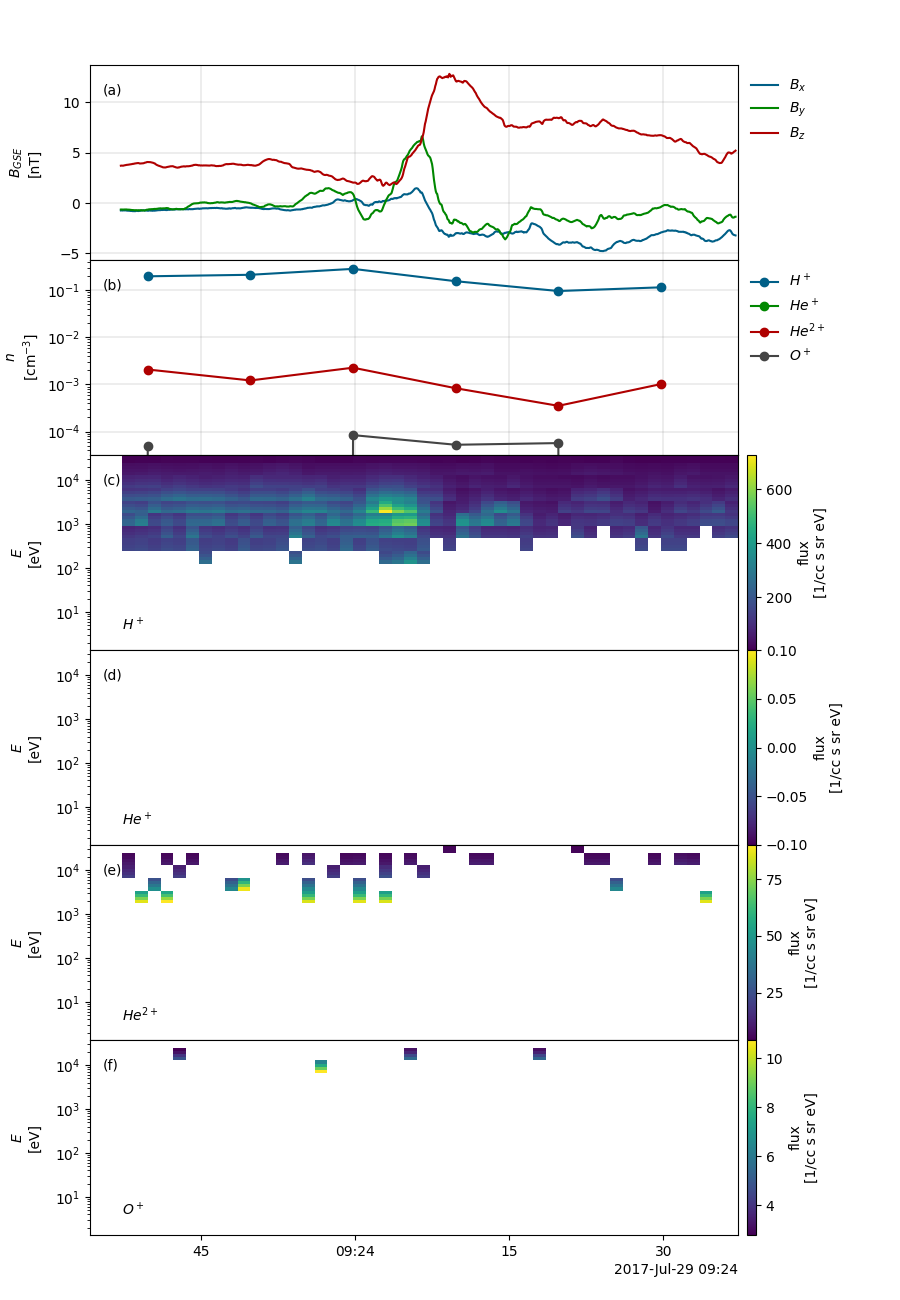

In [16]:
f, axs = plt.subplots(6, sharex="all", figsize=(9, 13))
f.subplots_adjust(hspace=0, left=0.1, right=0.82, bottom=0.05, top=0.95)


plot_line(axs[0], b_xyz)
axs[0].set_ylabel("$B_{GSE}$" + "\n" + "[nT]")
axs[0].legend(["$B_{x}$", "$B_{y}$", "$B_{z}$"], **legend_options)

labels = []
for n, s in zip(n_hpca, species.keys()):
    plot_line(axs[1], n, linestyle="-", marker="o")
    labels.append(species[s])

axs[1].set_yscale("log")
axs[1].set_ylabel("$n$" + "\n" + "[cm$^{-3}$]")
axs[1].legend(labels, **legend_options)

caxs = [None] * len(species)
for s, ax, cax, flux in zip(species.keys(), axs[2:], caxs, flux_hpca):
    ax, cax = plot_spectr(ax, flux, yscale="log",  cmap="viridis")
    ax.set_ylabel("$E$" + "\n" + "[eV]")
    cax.set_ylabel("flux" + "\n" + "[1/cc s sr eV]")
    ax.text(0.05, 0.1, species[s], transform=ax.transAxes)

f.align_ylabels(axs)
make_labels(axs, [0.02, 0.85])

[01-Jul-25 07:41:08] WARNING: <>:24: SyntaxWarning: invalid escape sequence '\l'

[01-Jul-25 07:41:08] WARNING: <>:28: SyntaxWarning: invalid escape sequence '\l'

[01-Jul-25 07:41:08] WARNING: <>:28: SyntaxWarning: invalid escape sequence '\m'

[01-Jul-25 07:41:08] WARNING: <>:24: SyntaxWarning: invalid escape sequence '\l'

[01-Jul-25 07:41:08] WARNING: <>:28: SyntaxWarning: invalid escape sequence '\l'

[01-Jul-25 07:41:08] WARNING: <>:28: SyntaxWarning: invalid escape sequence '\m'

[01-Jul-25 07:41:08] WARNING: /tmp/ipykernel_29326/4222656180.py:24: SyntaxWarning: invalid escape sequence '\l'
  caxs.set_ylabel("$\log_{10}$\nDPF" + "\n" + "[1/cc s sr eV]")

[01-Jul-25 07:41:08] WARNING: /tmp/ipykernel_29326/4222656180.py:28: SyntaxWarning: invalid escape sequence '\l'
  caxs.set_ylabel("$\log_{10}$\nDPF" + "\n" + "[$\mathrm{cm^{-3}~s^{-1}~sr^{-1}~eV^{-1}}$]")

[01-Jul-25 07:41:08] WARNING: /tmp/ipykernel_29326/4222656180.py:28: SyntaxWarning: invalid escape sequence '\m'
  caxs.set

array([<Axes: ylabel='$B_{GSE}$\n[nT]'>,
       <Axes: ylabel='$n$\n[cm$^{-3}$]'>,
       <Axes: ylabel='$V_{GSE}$\n[km/s]'>,
       <Axes: ylabel='$E$\n[eV]\n(survey)'>,
       <Axes: ylabel='$E$\n[eV]\n(burst)'>], dtype=object)

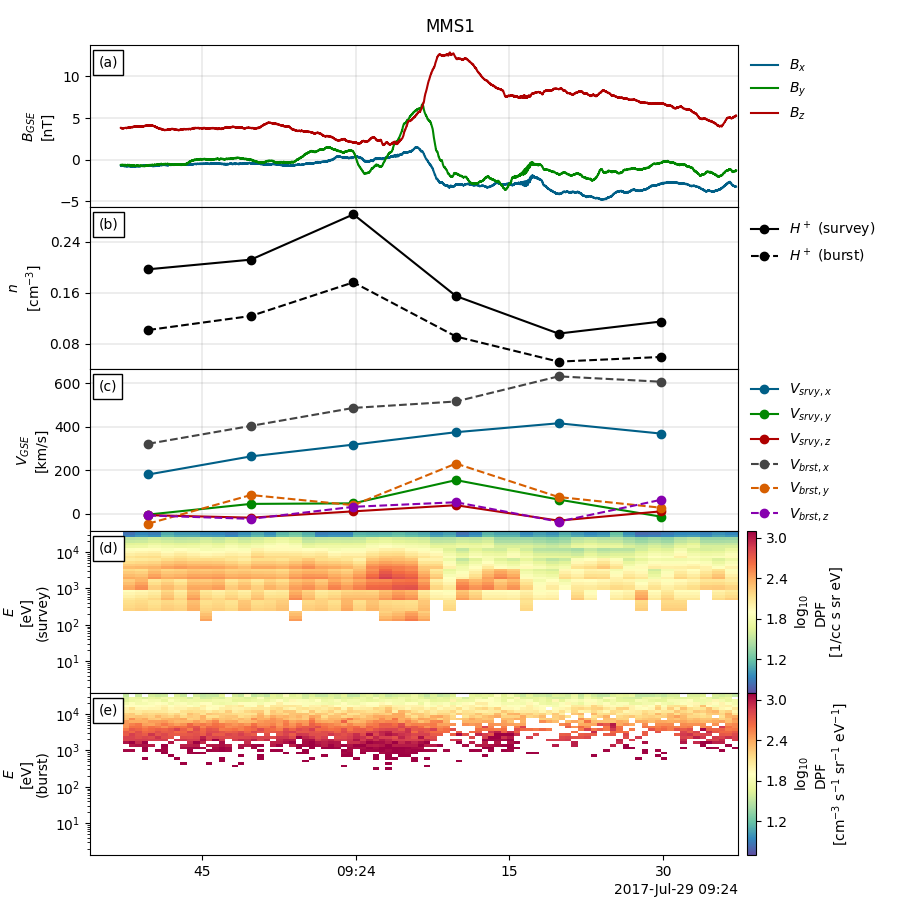

In [ ]:
fig, axs = plt.subplots(5, sharex="all", figsize=(9, 9))
fig.subplots_adjust(hspace=0, left=0.1, right=0.82, bottom=0.05, top=0.95)
fig.suptitle(f"MMS{ic}")
plot_line(axs[0], b_xyz_brst)
axs[0].set_ylabel("$B_{GSE}$" + "\n" + "[nT]")
axs[0].legend(["$B_{x}$", "$B_{y}$", "$B_{z}$"], **legend_options)

plot_line(axs[1], n_hpca[0], linestyle="-", color = "black", marker="o")
plot_line(axs[1], n_hpca_brst[0], linestyle="--", color = "black", marker="o")
axs[1].set_ylabel("$n$" + "\n" + "[cm$^{-3}$]")
axs[1].legend(
    ["$H^+$ (survey)", "$H^+$ (burst)"], **legend_options
)

plot_line(axs[2], v_xyz_hpca[0], linestyle="-", label = ["$V_{srvy, x}$", "$V_{srvy,y}$", "$V_{srvy,z}$"], marker ="o")
plot_line(axs[2], v_xyz_hpca_brst[0], linestyle="--", label = ["$V_{brst,x}$", "$V_{brst,y}$", "$V_{brst,z}$"], marker ="o")
axs[2].set_ylabel("$V_{GSE}$" + "\n" + "[km/s]")
axs[2].legend(
     **legend_options
)

axs[3], caxs = plot_spectr(axs[3], np.log10(flux_hpca[0]), yscale="log", cmap="Spectral_r", clim = [0.7, 3.1])
axs[3].set_ylabel("$E$" + "\n" + "[eV]" + "\n" + "(survey)")
caxs.set_ylabel("$\log_{10}$\nDPF" + "\n" + "[1/cc s sr eV]")

axs[4], caxs = plot_spectr(axs[4], np.log10(flux_hpca_brst[0]), yscale="log", cmap="Spectral_r", clim= [0.7, 3.1])
axs[4].set_ylabel("$E$" + "\n" + "[eV]" + "\n" + "(burst)")
caxs.set_ylabel("$\log_{10}$\nDPF" + "\n" + "[$\mathrm{cm^{-3}~s^{-1}~sr^{-1}~eV^{-1}}$]")
make_labels(axs, [0.013, 0.87], bbox = dict(facecolor = "white", edgecolor = "black"))
fig.savefig("hpca_hp_burst_survey.png", dpi=300, bbox_inches="tight")

In [37]:
import os
os.getcwd()

'/homelocal/apostolosk/irfu-python/docs/examples/01_mms'